<a href="https://colab.research.google.com/github/saffarizadeh/INSY5378/blob/main/Image_Classification_with_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://kambizsaffari.com/Logo/College_of_Business.cmyk-hz-lg.png" width="500px"/>

# *INSY 5378 - Advanced AI*

# **Image Classification with CNNs**

Instructor: Dr. Kambiz Saffari

---

Note: You MUST read the chapter. Going through this notebook does not replace the value of reading the chapter.

Link to the chapter: https://deeplearningwithpython.io/chapters/chapter08_image-classification/

> *Disclaimer: This notebook is a personal study guide created for educational purposes. It summarizes and references material from "Deep Learning with Python, Third Edition" by François Chollet and Matthew Watson (Manning Publications). All rights to the original content, including text, images, and code, belong to the respective authors and publisher. This notebook is not intended for commercial use or redistribution. Please support the authors by purchasing the book at Manning.*

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
!pip install keras keras-hub --upgrade -q

## Image Classification

This chapter covers:

- Understanding **convolutional neural networks** (ConvNets / CNNs)
- Using **data augmentation** to mitigate overfitting
- Using a **pretrained ConvNet** for feature extraction
- **Fine-tuning** a pretrained ConvNet

Computer vision was the first big success story of deep learning. A type of deep learning model called *convolutional neural networks* started achieving remarkable results on image classification competitions around 2011-2012, most notably when Hinton's group won the ImageNet challenge in 2012. Today, deep learning-based vision models power Google Photos, image search, phone cameras, YouTube, OCR software, autonomous driving, medical diagnosis, and much more.

---

**Key Terminology (Chapter 8 Glossary)**

| Term | Definition |
|------|------------|
| ConvNet (CNN) | A neural network that uses convolution layers to learn spatial hierarchies of patterns from images |
| Feature map | A rank-3 tensor output of a convolution layer, with spatial dimensions (height, width) and a depth (channels) axis |
| Filter / Kernel | A learned weight matrix that slides over the input to detect a specific pattern (e.g., edges, textures) |
| Padding | Adding rows/columns around the input so the output has the same spatial dimensions as the input (`"same"` vs `"valid"`) |
| Stride | The distance between successive convolution windows; stride > 1 downsamples the feature map |
| Max pooling | A downsampling operation that extracts the maximum value from each local patch of a feature map |
| Data augmentation | Generating more training data by applying random transformations (flips, rotations, zooms) to existing images |
| Pretrained model | A model previously trained on a large dataset (e.g., ImageNet) whose learned features can be reused |
| Feature extraction | Using the convolutional base of a pretrained model to extract features, then training a new classifier on top |
| Fine-tuning | Unfreezing some layers of a pretrained model and jointly training them with the new classifier |
| Convolutional base / Backbone | The convolution + pooling layers of a ConvNet (everything before the final classifier) |
| Freezing | Setting `trainable = False` on a layer to prevent its weights from being updated during training |

## Introduction to ConvNets

Let's start with a practical example: using a ConvNet to classify images from the **CIFAR-10** dataset. CIFAR-10 contains 60,000 color images (32x32 pixels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. This is a step up from simple digit recognition - these are real-world objects with complex shapes, textures, and backgrounds.

A ConvNet is a stack of `Conv2D` and `MaxPooling2D` layers. It takes as input tensors of shape `(image_height, image_width, image_channels)` - for CIFAR-10, that's `(32, 32, 3)` since the images are 32x32 pixels with 3 color channels (RGB).

Here is how the CIFAR-10 dataset looks:

<table>
    <tbody><tr>
        <td>airplane</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/airplane5.png"></td>
    </tr>
    <tr>
        <td>automobile</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/automobile5.png"></td>
    </tr>
    <tr>
        <td>bird</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/bird5.png"></td>
    </tr>
    <tr>
        <td>cat</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/cat5.png"></td>
    </tr>
    <tr>
        <td>deer</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/deer5.png"></td>
    </tr>
    <tr>
        <td>dog</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/dog5.png"></td>
    </tr>
    <tr>
        <td>frog</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/frog5.png"></td>
    </tr>
    <tr>
        <td>horse</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/horse5.png"></td>
    </tr>
    <tr>
        <td>ship</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/ship5.png"></td>
    </tr>
    <tr>
        <td>truck</td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck1.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck2.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck3.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck4.png"></td>
        <td><img src="https://www.cs.toronto.edu/~kriz/cifar-10-sample/truck5.png"></td>
    </tr>
</tbody></table>

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(32, 32, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 32, 32, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling (Rescaling)             │ (None, 32, 32, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 30, 30, 64)       │         1,792 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 15, 15, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 13, 13, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 6, 6, 128)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 4, 4, 256)        │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 256)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 373,386 (1.42 MB)

 Trainable params: 373,386 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

Notice how the spatial dimensions (height x width) shrink as we go deeper (32->30->15->13->6->4), while the number of channels grows (3->64->128->256). The Rescaling layer normalizes pixel values from [0, 255] to [0, 1].
After the last Conv2D layer, we need to convert the 3D feature map into a 1D vector before feeding it into the final Dense layer for classification. There are two common ways to do this:

* `Flatten()` unrolls all values into one long vector. For our (4, 4, 256) output, that would produce a vector of length 4 x 4 x 256 = 4,096. This preserves all spatial information but creates a large number of parameters in the next dense layer, which increases the risk of overfitting.
* `GlobalAveragePooling2D()` takes the average of each feature map, producing a much shorter vector of length 256. This drastically reduces the parameter count and acts as a form of regularization.

Both approaches are valid. We use `GlobalAveragePooling2D` here because it keeps the model lightweight, which is especially important when working with small datasets (as we will later in this chapter).

Note that unlike MNIST (grayscale, 1 channel), CIFAR-10 images have 3 color channels (RGB), making this a more realistic example of how ConvNets process real-world images.

**Making sense of the number of parameters in Conv2D layers**

To understand the number of parameters you can think about how many coefficients you need to calculate for each layer.
For example in the first Conv2D layer we need to calculate the coefficients for 64 filters. Each filter has a 3x3 kernel. Since the image is RGB colored, each filter requires 3 sets of 3x3 coefficients (one set per color channel, i.e., R, G, and B). So for each filter we need to calculate 3x3x3 = 27 coefficients. We also need an intercept (aka bias) term for each filter. So in total we need 3x3x3 + 1 = 28 coefficients per filter. We have 64 filters in this layer so in total we have 64x(3x3x3 + 1) = 1,792 parameters to calculate.
The general formula for calculating the number of parameters in a Conv2D layer is k(nml + 1), where k is the number of filters, n and m are the dimensions of the kernel, and l is the number of input channels. Therefore, for instance, for the second Conv2D layer the number of parameters is calculated as 128x(3x3x64 + 1) = 73,856. Please note that for this layer we have 64 input channels because the previous Conv2D layer converted the 3 RGB channels into 64 feature maps.

In [ ]:
from keras.datasets import cifar10

(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
print(f"Training data shape: {train_images.shape}")
print(f"Test data shape: {test_images.shape}")

# Note: we don't need to rescale here because the Rescaling layer is inside the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3652 - loss: 1.7107 - val_accuracy: 0.4666 - val_loss: 1.4510
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5046 - loss: 1.3722 - val_accuracy: 0.5584 - val_loss: 1.2325
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5665 - loss: 1.2190 - val_accuracy: 0.5962 - val_loss: 1.1492
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6070 - loss: 1.1126 - val_accuracy: 0.5958 - val_loss: 1.1550
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6348 - loss: 1.0379 - val_accuracy: 0.6176 - val_loss: 1.0531
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6590 - loss: 0.9710 - val_accuracy: 0.6922 - val_loss: 0.9143
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6823 - loss: 0.9133 - val_accuracy: 

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7032 - loss: 0.8505
Test accuracy: 0.703


CIFAR-10 is a significantly harder task than digit classification - with 10 classes of real-world objects in tiny 32x32 images, even a basic ConvNet can reach around 70-75% accuracy. A simple dense network would struggle to get much above 50% on this task, demonstrating the clear advantage of convolutions for image data. Why does this work so well? Let's understand the convolution operation.

### The Convolution Operation

The key difference between `Dense` layers and `Conv2D` layers:

- **Dense layers** learn **global** patterns (involving all pixels at once)
- **Convolution layers** learn **local** patterns (in small 2D windows, e.g. 3×3)

<img src="https://deeplearningwithpython.io/images/ch08/local_patterns.b72668dd.jpg" width="200px"/>

This gives ConvNets two powerful properties:

1. **Translation invariance**: A pattern learned in one part of the image can be recognized anywhere else. Dense layers would have to learn the same pattern separately for each location.

2. **Spatial hierarchy of patterns**: A first convolution layer learns small patterns (edges), a second layer learns patterns *made of* first-layer features (textures, corners), and deeper layers learn increasingly complex concepts.

<img src="https://deeplearningwithpython.io/images/ch08/visual_hierarchy_hires.40ec558e.png" width="300px"/>

#### How Convolution Works

Convolutions operate over rank-3 tensors called **feature maps** with two spatial axes (height, width) and a depth/channels axis. The convolution slides a small window (e.g. 3×3) over the input, extracts a patch at each location, transforms it via a learned **convolution kernel**, and reassembles the results into an output feature map.

<img src="https://deeplearningwithpython.io/images/ch08/response_map_hires.ab2ee335.png" width="500px"/>

The two key parameters of a convolution are:
- **Patch size**: typically 3×3 or 5×5
- **Output depth** (number of filters): how many different patterns the layer learns

<img src="https://deeplearningwithpython.io/images/ch08/how_convolution_works.fb611af4.png" width="400px"/>


#### Border Effects and Padding

The output of a convolution is smaller than the input due to **border effects**. For a 5×5 input with a 3×3 window, only 9 valid positions exist, producing a 3×3 output.

<img src="https://deeplearningwithpython.io/images/ch08/3x3_patches_in_5x5_input.3954b81b.png" width="300px"/>

To keep the same spatial dimensions, use **padding** - adding rows and columns around the input:

<img src="https://deeplearningwithpython.io/images/ch08/padding_of_5x5_input.fb864a53.png" width="300px"/>

In Keras: `Conv2D(..., padding="same")` adds padding to preserve dimensions; `padding="valid"` (default) uses no padding.

#### Convolution Strides

The **stride** is the distance between successive convolution windows (default is 1). Using stride 2 downsamples the feature map by a factor of 2.

<img src="https://deeplearningwithpython.io/images/ch08/strides.78c3a935.png" width="300px"/>

Strided convolutions are rarely used in classification models - instead, we use **max pooling** for downsampling.

### The Max-Pooling Operation

Max pooling extracts windows from the input and outputs the **maximum value** of each channel. It's typically done with 2×2 windows and stride 2, halving the feature map dimensions.

**Why is max pooling important?** Without it, the model would have two problems:

In [ ]:
# What happens without max pooling?
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(inputs)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(10, activation="softmax")(x)
model_no_max_pool = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model_no_max_pool.summary(line_length=80)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 32, 32, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 30, 30, 64)       │         1,792 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)                 │ (None, 28, 28, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)                 │ (None, 26, 26, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_1        │ (None, 256)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 10)               │         2,570 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 373,386 (1.42 MB)

 Trainable params: 373,386 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

Two problems with this model:

1. **No spatial hierarchy**: The 3x3 windows in the third layer only see information from 7x7 pixels of the original input - too small to recognize complex objects like cars or horses. With max pooling, each successive layer "sees" a larger fraction of the input.

2. **Huge final feature maps**: The final feature map is 26x26 - averaging over that destroys too much spatial information. With max pooling, the final map would be just 4x4, concentrating information into the channels.

In short, max pooling makes the information **less spatially distributed** and **more concentrated in the channels**, while creating a spatial hierarchy where deeper layers "look at" larger portions of the input.

---

## Training a ConvNet from Scratch on a Small Dataset

A common real-world scenario: you have very few training images (a few hundred to a few tens of thousands). We'll classify **dogs vs. cats** using only 2,000 training images, 1,000 validation images, and 2,000 test images from the Kaggle Dogs vs. Cats dataset.

Our plan:
1. **Baseline**: Train a small ConvNet from scratch → ~80% accuracy
2. **+ Data augmentation**: Fight overfitting → ~84% accuracy
3. **+ Pretrained model** (feature extraction & fine-tuning) → ~98.5% accuracy

<img src="https://deeplearningwithpython.io/images/ch08/dog_and_cat_samples.d2409a95.png" width="600px"/>


### The Relevance of Deep Learning for Small-Data Problems

ConvNets learn local, translation-invariant features, making them **highly data efficient** on perceptual problems. Even a few hundred images can suffice if the model is small and well regularized. Additionally, **pretrained models** allow you to reuse features learned on large datasets (like ImageNet with 1.4M images), which is one of the greatest strengths of deep learning: **feature reuse**.

### Downloading the Data

The Dogs vs. Cats dataset is hosted on Kaggle. Before downloading:
1. Sign in at https://www.kaggle.com/
2. Join the competition at https://www.kaggle.com/c/dogs-vs-cats/data
3. Generate a Kaggle API key at https://www.kaggle.com/settings

In [ ]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
download_path = kagglehub.competition_download("dogs-vs-cats")

100%|██████████| 812M/812M [00:20<00:00, 41.0MB/s]

Extracting files...


In [ ]:
import zipfile

with zipfile.ZipFile(download_path + "/train.zip", "r") as zip_ref:
    zip_ref.extractall(".")

We create a smaller subset: 1,000 training images per class, 500 validation, and 1,000 test. This simulates the common real-world scenario of having limited labeled data.

In [ ]:
import os, shutil, pathlib

original_dir = pathlib.Path("train")
new_base_dir = pathlib.Path("dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname, dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)       # 2,000 training images
make_subset("validation", start_index=1000, end_index=1500) # 1,000 validation images
make_subset("test", start_index=1500, end_index=2500)       # 2,000 test images

### Building the Model

We use a deeper ConvNet for this more complex task: five `Conv2D` + `MaxPooling2D` stages with increasing filter counts (32→64→128→256→512). A `Rescaling` layer normalizes pixel values from [0, 255] to [0, 1]. Since this is binary classification, we use a single sigmoid output.

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary(line_length=80)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)           │ (None, 180, 180, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)                 │ (None, 178, 178, 32)     │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)    │ (None, 89, 89, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)                 │ (None, 87, 87, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)    │ (None, 43, 43, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)                 │ (None, 41, 41, 128)      │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)    │ (None, 20, 20, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)                 │ (None, 18, 18, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)    │ (None, 9, 9, 256)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)                │ (None, 7, 7, 512)        │     1,180,160 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_2        │ (None, 512)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 1)                │           513 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 1,569,089 (5.99 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

### Data Preprocessing

We use `image_dataset_from_directory` to automatically load JPEG files, decode them, resize to 180×180, and batch them. It infers class labels from the subdirectory structure (`cat/` and `dog/`).

In [ ]:
from keras.utils import image_dataset_from_directory

batch_size = 64
image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


#### Understanding TensorFlow Dataset Objects

The `tf.data.Dataset` API creates efficient input pipelines with automatic parallelization and prefetching. A `Dataset` is an iterator that yields batches of data. It works with any Keras backend (JAX, PyTorch, TensorFlow).

Key methods: `.batch()`, `.shuffle()`, `.prefetch()`, and `.map()` for applying transformations.

In [ ]:
import numpy as np
import tensorflow as tf

# Create a Dataset from a NumPy array
random_numbers = np.random.normal(size=(1000, 16))
dataset = tf.data.Dataset.from_tensor_slices(random_numbers)

# Single samples
for i, element in enumerate(dataset):
    print(element.shape)
    if i >= 2:
        break

(16,)
(16,)
(16,)


In [ ]:
# Batching
batched_dataset = dataset.batch(32)
for i, element in enumerate(batched_dataset):
    print(element.shape)
    if i >= 2:
        break

(32, 16)
(32, 16)
(32, 16)


In [ ]:
# Using .map() to apply transformations
reshaped_dataset = dataset.map(
    lambda x: tf.reshape(x, (4, 4)),
    num_parallel_calls=8)
for i, element in enumerate(reshaped_dataset):
    print(element.shape)
    if i >= 2:
        break

(4, 4)
(4, 4)
(4, 4)


#### Fitting the Model

Each batch from the dataset yields images of shape `(batch_size, 180, 180, 3)` and integer labels of shape `(batch_size,)`. We use `ModelCheckpoint` with `save_best_only=True` to keep only the model state with the lowest validation loss.

In [ ]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (64, 180, 180, 3)
labels batch shape: (64,)


In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 445ms/step - accuracy: 0.5055 - loss: 0.6969 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5095 - loss: 0.6924 - val_accuracy: 0.6250 - val_loss: 0.6853
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.5425 - loss: 0.6904 - val_accuracy: 0.5560 - val_loss: 0.6715
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.6140 - loss: 0.6536 - val_accuracy: 0.6620 - val_loss: 0.6272
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.6130 - loss: 0.6478 - val_accuracy: 0.6450 - val_loss: 0.6302
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.6595 - loss: 0.6202 - val_accuracy: 0.6880 - val_loss: 0.5883
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.6740 - loss: 0.5995 - val_accuracy: 0.7030 - val_loss: 0.5764
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.6930 - loss: 0.5806 - val_accuracy: 0

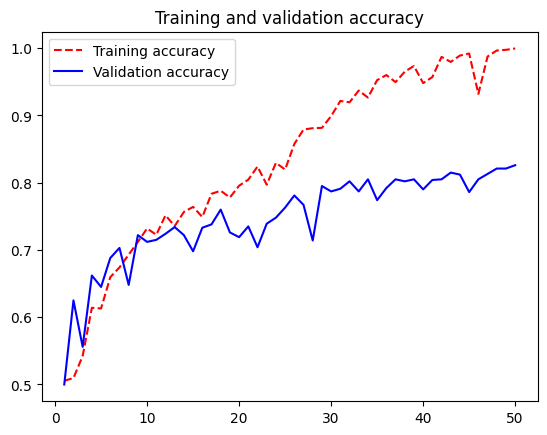

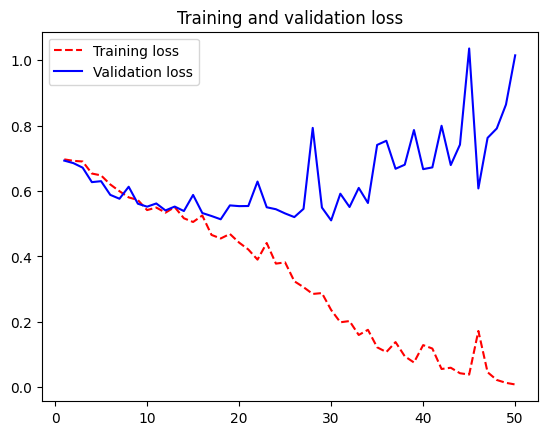

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

These plots show classic **overfitting**: training accuracy rises to ~100% while validation accuracy plateaus around 80%. The validation loss stops improving after ~10 epochs while training loss keeps decreasing. This is exactly what we expect with only 2,000 training samples.

In [ ]:
test_model = keras.models.load_model("convnet_from_scratch.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.7875 - loss: 0.5307
Test accuracy: 0.788


---

### Using Data Augmentation

**Data augmentation** generates more training data by applying random transformations to existing images. The model never sees the exact same image twice, which helps it generalize better.

Common augmentations:
- `RandomFlip("horizontal")` - flips 50% of images horizontally
- `RandomRotation(0.1)` - rotates by ±36 degrees
- `RandomZoom(0.2)` - zooms in/out by ±20%

We apply these in the data pipeline (on CPU) rather than inside the model (on GPU), which is usually the better option.

In [ ]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

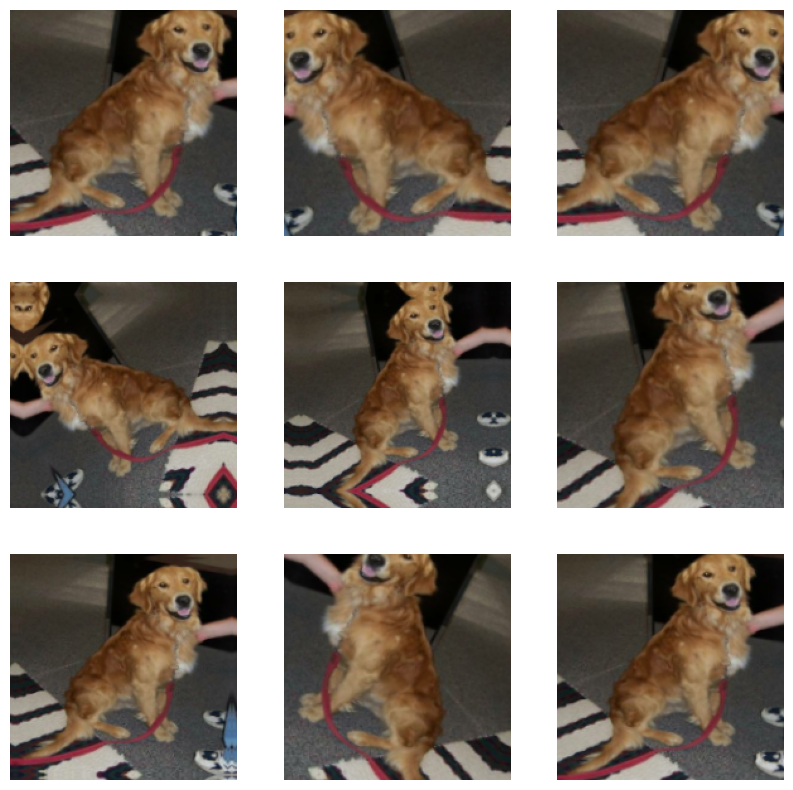

In [ ]:
plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image, _ = data_augmentation(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

Data augmentation alone isn't enough - the augmented images are still heavily correlated since they come from a small number of originals. We also add **Dropout** before the classifier to further fight overfitting.

In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1.0 / 255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch_with_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=100,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 463ms/step - accuracy: 0.5035 - loss: 0.7028 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 447ms/step - accuracy: 0.5120 - loss: 0.6903 - val_accuracy: 0.5690 - val_loss: 0.6842
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 476ms/step - accuracy: 0.5405 - loss: 0.6880 - val_accuracy: 0.5130 - val_loss: 0.6897
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 451ms/step - accuracy: 0.5570 - loss: 0.6860 - val_accuracy: 0.6140 - val_loss: 0.6687
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 444ms/step - accuracy: 0.5710 - loss: 0.6741 - val_accuracy: 0.5890 - val_loss: 0.6508
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 455ms/step - accuracy: 0.6075 - loss: 0.6576 - val_accuracy: 0.5880 - val_loss: 0.6422
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 450ms/step - accuracy: 0.6245 - loss: 0.6492 - val_accuracy: 0.6510 - val_loss: 0.6253
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 449ms/step - accuracy: 0.6540 - loss: 0.6333 - 

With data augmentation and dropout, overfitting is delayed until around epoch 60-70 (vs. epoch 10 before), and validation accuracy peaks above 85%.

<img src="https://deeplearningwithpython.io/images/ch08/cats-and-dogs-1-training-and-validation-da-acc.95f4446c.png" width="400px"/>
<img src="https://deeplearningwithpython.io/images/ch08/cats-and-dogs-1-training-and-validation-da-loss.fb77981b.png" width="400px"/>

In [ ]:
test_model = keras.models.load_model(
    "convnet_from_scratch_with_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8540 - loss: 0.4113
Test accuracy: 0.854


Test accuracy improves to ~85%. Good progress, but to go higher we need **pretrained models**.

---

## Using a Pretrained Model

A **pretrained model** was previously trained on a large dataset (e.g., ImageNet - 1.4M images, 1,000 classes). Its learned feature hierarchy can serve as a generic model of the visual world, useful even for completely different classification tasks.

Two approaches:
1. **Feature extraction** - Use the pretrained convolutional base to extract features, train a new classifier on top
2. **Fine-tuning** - Unfreeze some pretrained layers and jointly train them with the new classifier

We'll use the **Xception** architecture (41 trainable layers) via the **KerasHub** library.

### Feature Extraction with a Pretrained Model

The key insight: the **convolutional base** (backbone) learns generic visual features that transfer across tasks, while the **classifier head** is task-specific. We reuse only the backbone.

<img src="https://deeplearningwithpython.io/images/ch08/swapping_fc_classifier.6e525b7a.png" width="500px"/>

Earlier layers extract generic features (edges, colors, textures) while deeper layers extract more specialized features ("cat ear", "dog eye"). If your new task is very different from the original, you might only use the early layers.

In [ ]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

In [ ]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

#### Fast Feature Extraction (without Data Augmentation)

The fast approach: run all images through the pretrained backbone once, save the extracted features as NumPy arrays, then train a small classifier on those features. This is very fast but doesn't allow data augmentation.

In [ ]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [ ]:
train_features.shape

(2000, 6, 6, 2048)

The extracted features have shape `(2000, 6, 6, 2048)` - 2,048 feature maps of size 6×6. Now we train a simple classifier on these features:

In [ ]:
inputs = keras.Input(shape=(6, 6, 2048))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9570 - loss: 0.1022 - val_accuracy: 0.9750 - val_loss: 0.0660
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9880 - loss: 0.0333 - val_accuracy: 0.9850 - val_loss: 0.0453
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9920 - loss: 0.0201 - val_accuracy: 0.9850 - val_loss: 0.0501
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9965 - loss: 0.0121 - val_accuracy: 0.9860 - val_loss: 0.0475
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9975 - loss: 0.0066 - val_accuracy: 0.9870 - val_loss: 0.0475
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9990 - loss: 0.0048 - val_accuracy: 0.9800 - val_loss: 0.0784
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9860 - val_loss: 0.0548
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 9.5589e-04 - val_accuracy: 0.9860 -

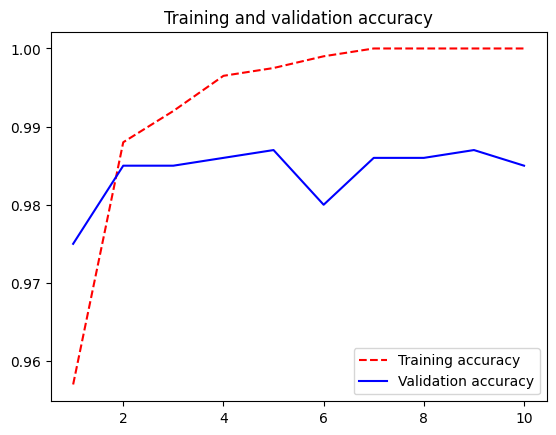

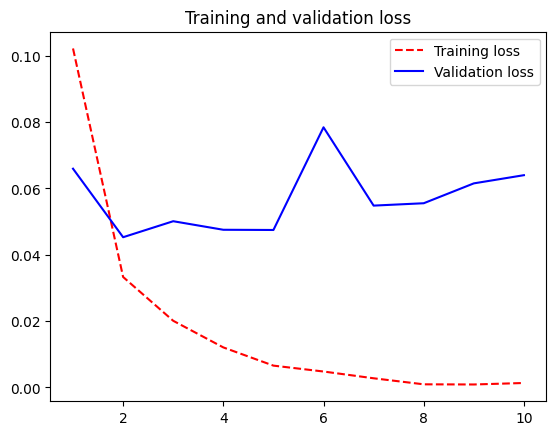

In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Validation accuracy jumps to ~98%! This is a massive improvement, though partly because ImageNet already contains many dog and cat classes. Note that overfitting starts almost immediately despite dropout, since we're not using data augmentation.


In [ ]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9825 - loss: 0.0521
Test accuracy: 0.983


#### Feature Extraction with Data Augmentation

The slower but more powerful approach: chain the frozen pretrained backbone with a new classifier and train end-to-end, so data augmentation can be applied. The key step is **freezing** the pretrained backbone (`trainable=False`) to prevent destroying its learned representations.

In [ ]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [ ]:
# Demonstrating the effect of freezing
conv_base.trainable = True
print(f"Trainable weights (unfrozen): {len(conv_base.trainable_weights)}")

conv_base.trainable = False
print(f"Trainable weights (frozen): {len(conv_base.trainable_weights)}")

Trainable weights (unfrozen): 154
Trainable weights (frozen): 0


In [ ]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9265 - loss: 0.1824 - val_accuracy: 0.9840 - val_loss: 0.0509
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 481ms/step - accuracy: 0.9750 - loss: 0.0914 - val_accuracy: 0.9830 - val_loss: 0.0532
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 468ms/step - accuracy: 0.9695 - loss: 0.0810 - val_accuracy: 0.9820 - val_loss: 0.0554
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 501ms/step - accuracy: 0.9770 - loss: 0.0691 - val_accuracy: 0.9800 - val_loss: 0.0576
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 495ms/step - accuracy: 0.9755 - loss: 0.0632 - val_accuracy: 0.9870 - val_loss: 0.0604
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 488ms/step - accuracy: 0.9800 - loss: 0.0516 - val_accuracy: 0.9840 - val_loss: 0.0581
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 517ms/step - accuracy: 0.9795 - loss: 0.0654 - val_accuracy: 0.9860 - val_loss: 0.0466
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.9760 - loss: 0.0689 - val_accurac

<img src="https://deeplearningwithpython.io/images/ch08/training-and-validation-feda-acc.b0c05268.png" width="400px"/>
<img src="https://deeplearningwithpython.io/images/ch08/training-and-validation-feda-loss.69d30842.png" width="400px"/>

This technique requires a GPU - it's intractable on CPU since every image passes through the full backbone during each epoch.

In [ ]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 274ms/step - accuracy: 0.9840 - loss: 0.0531
Test accuracy: 0.984


---

### Fine-Tuning a Pretrained Model

**Fine-tuning** goes one step further: after training the classifier on frozen features, we **unfreeze** the pretrained backbone and jointly train everything with a very low learning rate. This slightly adjusts the pretrained representations to be more relevant for our specific task.

The steps:
1. Add a custom classifier on top of the pretrained backbone
2. Freeze the backbone
3. Train the classifier
4. Unfreeze the backbone (or just its top layers)
5. Jointly train both with a **very low learning rate**

Why a low learning rate? To limit the magnitude of changes to the pretrained representations - large updates would destroy them.

**Important**: Do not unfreeze `BatchNormalization` layers during fine-tuning (explained in Chapter 9).

**Partial fine-tuning**: For large models, you can unfreeze only the top few layers (which encode more task-specific features) while keeping earlier layers frozen (which encode generic features like edges and textures). This also reduces the risk of overfitting.

In [ ]:
# Step 4: Unfreeze the backbone for fine-tuning
conv_base.trainable = True

# Step 5: Recompile with a very low learning rate
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9095 - loss: 0.2154 - val_accuracy: 0.9810 - val_loss: 0.0661
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 944ms/step - accuracy: 0.9320 - loss: 0.1598 - val_accuracy: 0.9790 - val_loss: 0.0596
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 730ms/step - accuracy: 0.9540 - loss: 0.1206 - val_accuracy: 0.9810 - val_loss: 0.0607
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 741ms/step - accuracy: 0.9600 - loss: 0.1033 - val_accuracy: 0.9810 - val_loss: 0.0621
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 707ms/step - accuracy: 0.9640 - loss: 0.0868 - val_accuracy: 0.9810 - val_loss: 0.0654
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 717ms/step - accuracy: 0.9585 - loss: 0.0935 - val_accuracy: 0.9760 - val_loss: 0.0677
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 715ms/step - accuracy: 0.9685 - loss: 0.0871 - val_accuracy: 0.9770 - val_loss: 0.0678
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 709ms/step - accuracy: 0.9790 - loss: 0.0541 - val_accura

<img src="https://deeplearningwithpython.io/images/ch08/training-and-validation-ft-acc.7ec17959.png" width="400px"/>
<img src="https://deeplearningwithpython.io/images/ch08/training-and-validation-ft-loss.3c4293eb.png" width="400px"/>


In [ ]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 235ms/step - accuracy: 0.9785 - loss: 0.0746
Test accuracy: 0.979


Fine-tuning reaches ~97.9% test accuracy - competitive with the top results in the original Kaggle competition, despite using only ~10% of the available training data.

---

## Summary

**Key takeaways from this chapter:**

- **ConvNets** are the go-to architecture for computer vision. They learn spatial hierarchies of patterns (edges → textures → object parts → objects) through convolution and pooling operations.

- **Convolution** learns local, translation-invariant patterns. **Max pooling** downsamples feature maps to create spatial hierarchies and concentrate information into channels.

- On small datasets, **overfitting** is the main challenge. **Data augmentation** (random flips, rotations, zooms) is a powerful regularization technique specific to computer vision.

- **Pretrained models** enable excellent performance even with very few training samples by reusing features learned from large datasets like ImageNet.

- **Feature extraction**: Use a frozen pretrained backbone to compute features, then train a new classifier on those features. Fast and effective.

- **Fine-tuning**: After feature extraction, unfreeze the backbone and train everything jointly with a very low learning rate. With enough epochs, this typically squeezes out the last few percentage points of accuracy.

---

**Accuracy progression on Dogs vs. Cats (2,000 training samples):**

| Approach | Test Accuracy |
|----------|---------------|
| ConvNet from scratch | ~78.8% |
| + Data augmentation & dropout | ~85.4% |
| Pretrained feature extraction (no augmentation) | ~98.3% |
| Pretrained feature extraction + augmentation | ~98.4% |
| Fine-tuning | ~97.9% |

These three strategies - training from scratch, feature extraction, and fine-tuning - form your complete toolbox for tackling image classification with small datasets.